# Avance Proyecto: Beijing PM 2.5
### Tomás Saavedra 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
import joblib

## Lectura de Datos

El conjunto de datos Beijing PM2.5 contiene mediciones horarias de calidad del aire y variables meteorológicas registradas en la ciudad de Pekín, China, entre los años 2010 y 2014. El dataset incluye información sobre la concentración de partículas finas PM2.5, así como variables ambientales como temperatura, presión atmosférica, punto de rocío, velocidad y dirección del viento, lluvia y nieve. Su principal objetivo es permitir el análisis y la predicción de los niveles de contaminación atmosférica a partir de condiciones meteorológicas y temporales.

| Variable | Descripción | Unidad |
|-----------|-------------|---------|
| No | Índice secuencial de la observación | - |
| year | Año de la medición | - |
| month | Mes de la medición (1–12) | - |
| day | Día del mes | - |
| hour | Hora del día (0–23) | - |
| pm2.5 | Concentración de partículas PM2.5 en el aire | μg/m³ |
| DEWP | Punto de rocío (Dew Point) | °C |
| TEMP | Temperatura ambiente | °C |
| PRES | Presión atmosférica | hPa |
| cbwd | Dirección combinada del viento (Combined Wind Direction) | Categórica |
| Iws | Velocidad acumulada del viento (Cumulated Wind Speed) | m/s |
| Is | Horas acumuladas de nieve (Cumulated Hours of Snow) | horas |
| Ir | Horas acumuladas de lluvia (Cumulated Hours of Rain) | horas |

In [2]:
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")
print(df.head())
np.shape(df)

   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0


(43824, 13)

## EDA

In [3]:
print("--- Resumen General ---")
print(df.info())

print("\n--- Valores Faltantes ---")
print(df.isnull().sum())

print("\n--- Estadística Descriptiva de las Variables Numéricas ---")
print(df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']].describe().round(2))

print("\n--- Duplicados ---")
print("Duplicados encontrados:", df.duplicated().sum())

--- Resumen General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB
None

--- Valores Faltantes ---
No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

--- Estadística Descri

In [4]:
print("Valores 0 en pm2.5:", int((df["pm2.5"] == 0).sum()))

Valores 0 en pm2.5: 2


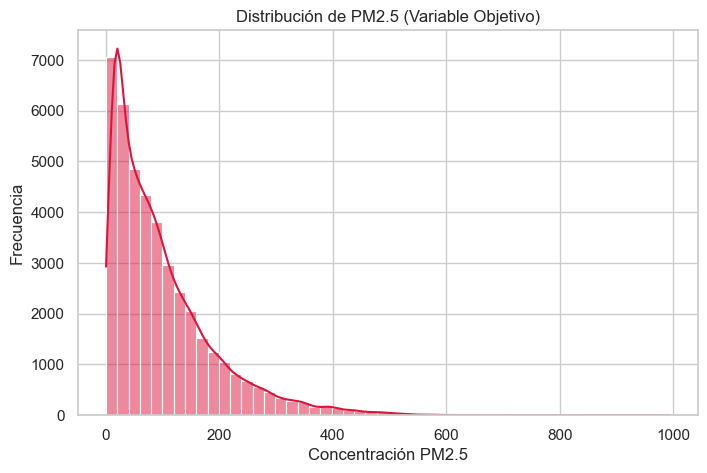

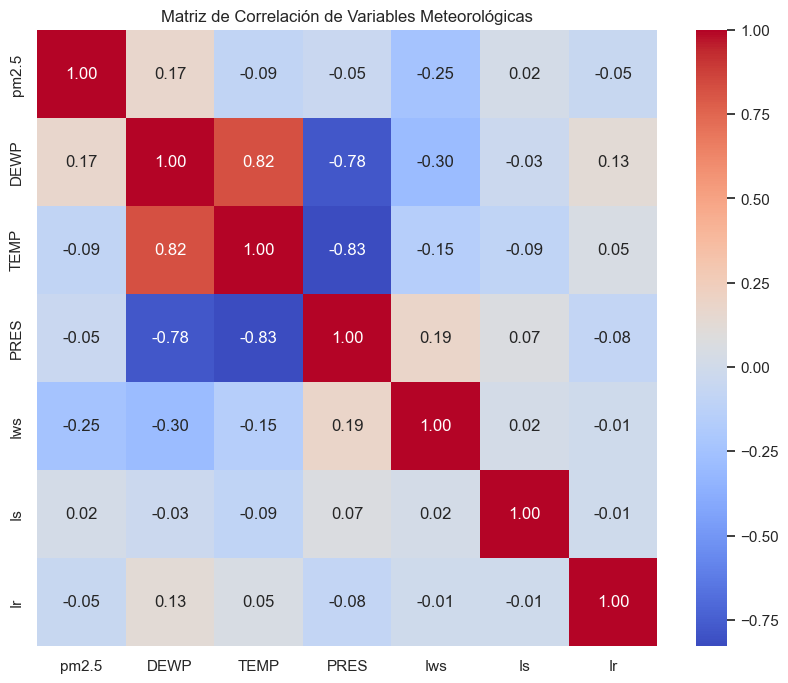

C:\Users\Public\ipykernel_10952\1185374921.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cbwd', y='pm2.5', data=df, palette="Set2")


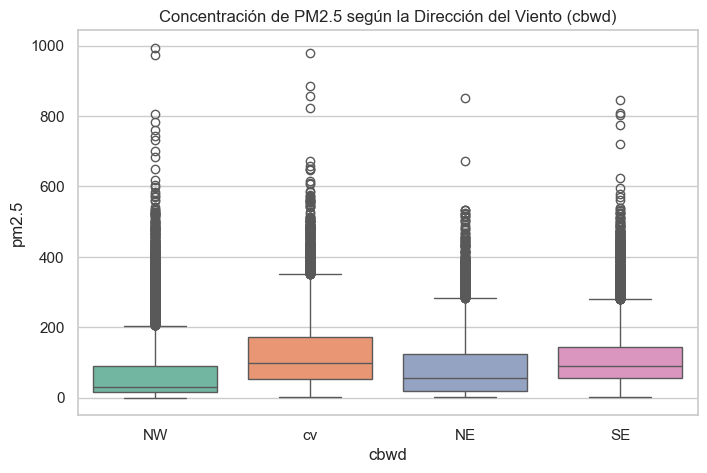

In [5]:
sns.set_theme(style="whitegrid")

# Visualización A: Distribución de PM2.5 (Variable Objetivo)
plt.figure(figsize=(8, 5))
sns.histplot(df['pm2.5'].dropna(), bins=50, kde=True, color="crimson")
plt.title('Distribución de PM2.5 (Variable Objetivo)')
plt.xlabel('Concentración PM2.5')
plt.ylabel('Frecuencia')
plt.show()

# Visualización B: Matriz de Correlación (Variables Numéricas)
plt.figure(figsize=(10, 8))
# Seleccionamos las columnas meteorológicas predictoras
cols_numericas = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
sns.heatmap(df[cols_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Meteorológicas')
plt.show()

# Visualización C: Relación con Variable Categórica (Dirección del Viento)
plt.figure(figsize=(8, 5))
sns.boxplot(x='cbwd', y='pm2.5', data=df, palette="Set2")
plt.title('Concentración de PM2.5 según la Dirección del Viento (cbwd)')
plt.show()

## Preprocesamiento

In [6]:
#Eliminar NAs
df_limpio = df.dropna(subset=["pm2.5"])
np.shape(df_limpio)

(41757, 13)

La variable PM2.5 presenta 2067 valores faltantes (4.7% de los registros). Debido a que esta variable corresponde a la variable objetivo del problema de regresión, los registros con valores faltantes fueron eliminados

In [7]:
# Eliminar columnas
columnas_a_eliminar = ['No', 'year', 'month', 'day', 'hour']
df_limpio = df_limpio.drop(columns=columnas_a_eliminar)

df_limpio = pd.get_dummies(df_limpio, columns=['cbwd'], drop_first=True, dtype=int) #Codificación

# División del conjunto
X = df_limpio.drop(columns=['pm2.5'])
y = np.log1p(df_limpio['pm2.5'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42) #70% entrenamiento
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42) #15% val 15% test

#Transformación de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n--- Dimensiones Finales de los Conjuntos ---")
print(f"Entrenamiento (70%): {X_train_scaled.shape}")
print(f"Validación (15%): {X_val_scaled.shape}")
print(f"Testeo (15%): {X_test_scaled.shape}")


--- Dimensiones Finales de los Conjuntos ---
Entrenamiento (70%): (29229, 9)
Validación (15%): (6264, 9)
Testeo (15%): (6264, 9)


## Construcción del modelo MLP

In [8]:
tf.random.set_seed(42)

modelo_mlp = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(124, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

modelo_mlp.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

modelo_mlp.summary()

historial = modelo_mlp.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(X_val_scaled, y_val), verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 124)                 │           1,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,305 (36.35 KB)

 Trainable params: 9,305 (36.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9847 - mae: 0.7049 - val_loss: 0.5591 - val_mae: 0.5828
Epoch 2/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5268 - mae: 0.5715 - val_loss: 0.5503 - val_mae: 0.5762
Epoch 3/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5171 - mae: 0.5653 - val_loss: 0.5426 - val_mae: 0.5714
Epoch 4/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5113 - mae: 0.5619 - val_loss: 0.5368 - val_mae: 0.5681
Epoch 5/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5070 - mae: 0.5595 - val_loss: 0.5324 - val_mae: 0.5658
Epoch 6/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5033 - mae: 0.5573 - val_loss: 0.5271 - val_mae: 0.5630
Epoch 7/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5008 - mae: 0.5558 - val_loss: 0.5256 - val_mae: 0.5624
Epoch 8/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4983 - mae: 0.5543 - val_loss: 0.5227 - val_mae: 0.5608
Epoch 9/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/

In [9]:
y_pred_log = modelo_mlp.predict(X_test_scaled)
y_pred_log = y_pred_log.flatten()

y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [10]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)

print("Resultados MLP Base")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

Resultados MLP Base
RMSE: 73.08
MAE : 47.39
R²  : 0.3693


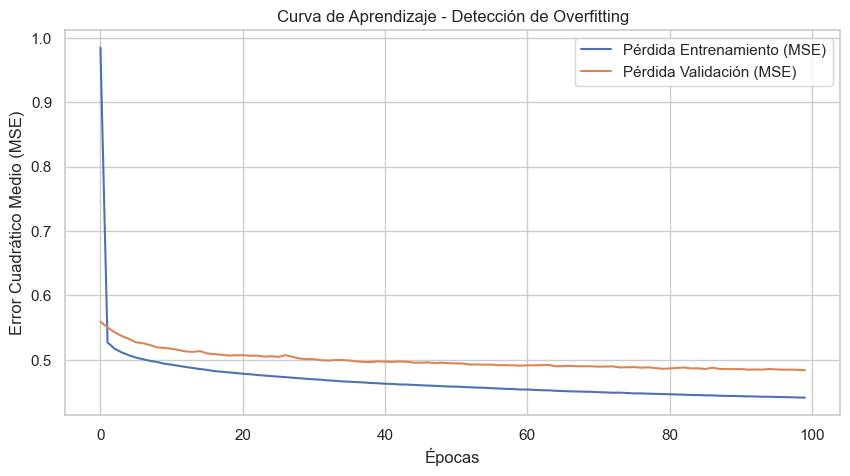

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(historial.history['loss'], label='Pérdida Entrenamiento (MSE)')
plt.plot(historial.history['val_loss'], label='Pérdida Validación (MSE)')
plt.title('Curva de Aprendizaje - Detección de Overfitting')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Modelo de Regresión Lineal

In [12]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred_log_lr = modelo_lr.predict(X_test_scaled) #Las predicciones saldrán en escala logarítmica porque el modelo fue entrenado con y_train
#vuelve a la escala original
y_pred_lr = np.expm1(y_pred_log_lr)
y_real = np.expm1(y_test)

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

rmse_lr = np.sqrt(mean_squared_error(y_real, y_pred_lr))
mae_lr = mean_absolute_error(y_real, y_pred_lr)
r2_lr = r2_score(y_real, y_pred_lr)

print("Resultados Regresión Lineal")
print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE : {mae_lr:.2f}")
print(f"R²  : {r2_lr:.4f}")

Resultados Regresión Lineal
RMSE: 82.77
MAE : 52.40
R²  : 0.1910


## MLP con búsqueda de hiperparámetros

In [15]:
import keras_tuner as kt
from keras_tuner.tuners import BayesianOptimization
import shutil

In [16]:
def build_model(n_hidden, n_neurons_init, activation, learning_rate, input_shape):

    model = keras.Sequential()
    model.add(keras.Input(shape=input_shape))

    for k in range(n_hidden):
        n_k = int(n_neurons_init * (0.6 ** k))

        if activation == "relu":
            model.add(keras.layers.Dense(n_k, activation="relu",kernel_initializer="he_normal"))

        elif activation == "tanh":
            model.add(keras.layers.Dense(n_k, activation="tanh"))

        elif activation == "elu":
            model.add(keras.layers.Dense(n_k))
            model.add(keras.layers.ELU(alpha=0.15))

    model.add(keras.layers.Dense(1, activation="linear"))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])

    return model

In [17]:
def build_model_tuner(hp):
    return build_model(
        n_hidden=hp.Int("n_hidden", min_value=1, max_value=4, step=1),
        n_neurons_init=hp.Choice("n_neurons_init", values=[32, 64, 128, 256]),
        activation=hp.Choice("activation", values=["relu", "tanh", "elu"]),
        learning_rate=hp.Choice("learning_rate", values=[0.01, 0.001, 0.0001]),
        input_shape=(X_train_scaled.shape[1],))

In [18]:
shutil.rmtree("my_dir", ignore_errors=True)

In [19]:
tuner = BayesianOptimization(
    build_model_tuner,
    objective="val_loss",
    max_trials=30, 
    executions_per_trial=1,
    directory="my_dir",
    project_name="pm25_mlp",
    seed=42
)

In [20]:
early_stopping_cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

In [21]:
tuner.search(X_train_scaled, y_train, epochs=100, validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping_cb], verbose=1) 

Trial 30 Complete [00h 04m 20s]
val_loss: 0.4797610640525818

Best val_loss So Far: 0.47601306438446045
Total elapsed time: 01h 43m 53s


In [22]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

n_hidden = best_hps.get("n_hidden")
n_init = best_hps.get("n_neurons_init")
activation = best_hps.get("activation")
learning_rate = best_hps.get("learning_rate")

neuronas_por_capa = [
    int(n_init * (0.6 ** k))
    for k in range(n_hidden)
]

print("Mejores hiperparámetros encontrados:")
print(f"Número de capas ocultas: {n_hidden}")
print(f"Neuronas por capa: {neuronas_por_capa}")
print(f"Función de activación: {activation}")
print(f"Learning rate: {learning_rate}")

Mejores hiperparámetros encontrados:
Número de capas ocultas: 2
Neuronas por capa: [256, 153]
Función de activación: elu
Learning rate: 0.001


In [23]:
best_model = build_model(n_hidden=n_hidden, n_neurons_init=n_init, activation=activation,
    learning_rate=learning_rate, input_shape=(X_train_scaled.shape[1],))

history_best = best_model.fit(X_train_scaled, y_train, epochs=100, validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping_cb], verbose=1)

Epoch 1/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.7930 - mae: 0.6545 - val_loss: 0.6117 - val_mae: 0.6045
Epoch 2/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5373 - mae: 0.5770 - val_loss: 0.5967 - val_mae: 0.5977
Epoch 3/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5248 - mae: 0.5701 - val_loss: 0.5775 - val_mae: 0.5882
Epoch 4/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5166 - mae: 0.5656 - val_loss: 0.5683 - val_mae: 0.5831
Epoch 5/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5113 - mae: 0.5625 - val_loss: 0.5507 - val_mae: 0.5747
Epoch 6/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5069 - mae: 0.5599 - val_loss: 0.5395 - val_mae: 0.5694
Epoch 7/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5033 - mae: 0.5578 - val_loss: 0.5312 - val_mae: 0.5653
Epoch 8/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5004 - mae: 0.5561 - val_loss: 0.5244 - val_mae: 0.5619
Epoch 9/100
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/

In [24]:
y_pred_log = best_model.predict(X_test_scaled)
y_pred_log = y_pred_log.flatten()

y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

rmse_best = np.sqrt(mean_squared_error(y_real, y_pred))
mae_best = mean_absolute_error(y_real, y_pred)
r2_best = r2_score(y_real, y_pred)

print("Resultados MLP Optimizado")
print(f"RMSE: {rmse_best:.2f}")
print(f"MAE : {mae_best:.2f}")
print(f"R²  : {r2_best:.4f}")

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Resultados MLP Optimizado
RMSE: 74.62
MAE : 47.12
R²  : 0.3426


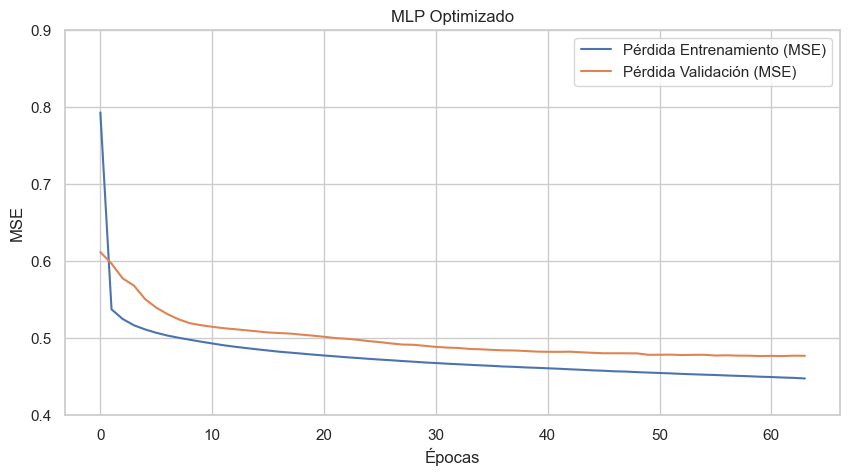

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(history_best.history['loss'], label='Pérdida Entrenamiento (MSE)')
plt.plot(history_best.history['val_loss'], label='Pérdida Validación (MSE)')
plt.title('MLP Optimizado')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.ylim(0.4,0.9)
plt.legend()
plt.grid(True)
plt.show()

In [26]:
tabla_resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "MLP Base", "MLP Optimizado"],
    "RMSE": [rmse_lr, rmse, rmse_best],
    "MAE": [mae_lr, mae, mae_best],
    "R²": [r2_lr, r2, r2_best]
})
tabla_resultados

,Modelo,RMSE,MAE,R²
0,Regresión Lineal,82.771293,52.401218,0.190995
1,MLP Base,73.084672,47.386137,0.369269
2,MLP Optimizado,74.615117,47.115700,0.342576


### Guardar el modelo

In [27]:
import os

os.makedirs("modelo_guardado", exist_ok=True)
modelo_mlp.save("modelo_guardado/modelo_pm25.keras")

#Guarda el scaler usado en el preprocesamiento
joblib.dump(scaler, "modelo_guardado/scaler_pm25.pkl")

# Guarda el orden/nombre de las columnas finales
columnas_finales = X_train.columns.tolist()
joblib.dump(columnas_finales, "modelo_guardado/columnas_pm25.pkl")

print("Modelo, scaler y columnas guardados correctamente.")

Modelo, scaler y columnas guardados correctamente.
